In [3]:
from pathlib import Path

main_dir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE/IntrinsicLVCPrior/")
four_images = main_dir / "unlensed_samples"

indir = four_images /"MD_SDSS_u_167/run_0"

In [8]:
import pandas as pd

bilby_samples = pd.read_feather(indir / "bilby_style_samples.feather")
bilby_samples.keys()

Index(['mass_1', 'mass_2', 'spin_1z', 'spin_2z', 'iota', 'luminosity_distance',
       'ra', 'dec', 'phase', 'psi', 'geocent_time', 'lnlike', 'spin_1x',
       'spin_1y', 'spin_2x', 'spin_2y', 'theta_jn', 'a_1', 'a_2', 'tilt_1',
       'tilt_2', 'phi_12', 'phi_jl', 'mass_ratio', 'chirp_mass',
       'cos_theta_jn', 'sin_dec', 'chi_eff', 'chi_1_in_plane',
       'chi_2_in_plane', 'chi_p'],
      dtype='object')

Text(0.5, 0, '$m_1\\,/\\,M_\\odot$')

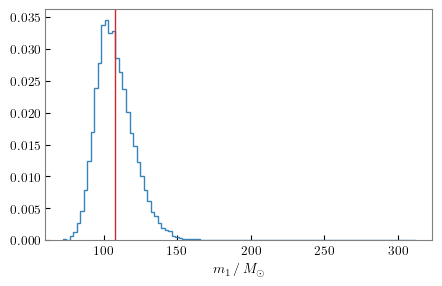

In [33]:
kwargs = {'bins': 100, 'density': True, 'alpha': 0.9, 'histtype': 'step'}


injection_dict = json.loads(npz_file['injection'].tobytes())['par_dic']

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(bilby_samples["mass_1"], **kwargs, label=r"$\log{\cal L}$")
ax.axvline(injection_dict['m1'], c='C3')
ax.set_xlabel(r"$m_1\,/\,M_\odot$")

In [34]:
npz_file['injection']

array('{"par_dic": {"m1": 107.54522437408797, "m2": 90.48919102318564, "s1x_n": -0.1365016787132557, "s2x_n": 0.165200470213044, "s1y_n": -0.3693471938368015, "s2y_n": 0.0018326274733109, "s1z": 0.3981439922304007, "s2z": 0.0156885954670572, "l1": 0.0, "l2": 0.0, "d_luminosity": 13776.3093628247, "iota": 0.3464136166276804, "ra": 1.504290067217061, "dec": 0.2137301669009347, "psi": 1.059233633635144, "phi_ref": 5.612145412584412, "t_geocenter": 0, "f_ref": 20.0, "SNR_net": 8.278290809467437}, "approximant": "IMRPhenomXPHM", "d_h": [25.254966520674657, 33.14098701815903, 6.903234074441445], "h_h": [27.57026127632634, 32.35653365667439, 3.9695340811560413]}',
      dtype='<U656')

107.54522437408797

In [32]:
def dehnen_profile(r, rhos, rs, alpha, beta, gamma):
    """Dehnen profile."""
    return rhos * (r / rs) ** (-gamma) * (1 + (r / rs)**alpha) ** ((gamma - beta)/alpha)

def nfw_profile(r, rhos, rs):
    """NFW profile."""
    return rhos / ((r / rs) * (1 + r / rs)**2)

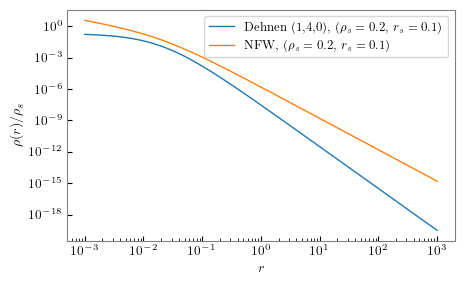

In [33]:
Rs = np.geomspace(1e-3, 1e3, 100)
fig, ax = plt.subplots(figsize=(5, 3))
ax.loglog(Rs, dehnen_profile(Rs / 0.2, rhos=0.2, rs=0.1, alpha=1, beta=4, gamma=0), label=r"Dehnen (1,4,0), ($\rho_s = 0.2$, $r_s = 0.1$)")
ax.loglog(Rs, nfw_profile(Rs / 0.2, rhos=0.2, rs=0.1), label=r"NFW, ($\rho_s = 0.2$, $r_s = 0.1$)")
ax.set_xlabel("$r$")
ax.set_ylabel(r"$\rho(r) / \rho_s$")
ax.legend()

In [7]:
import json

with open(indir / "MD_SDSS_u_167_metadata.json", "r") as jf:
    metadata = json.load(jf)

In [5]:
metadata['log_ev_NIS']

3.849133249491763

In [15]:
npz_file = np.load(indir / 'MD_SDSS_u_167.npz')
list(npz_file.keys())

['eventname',
 'frequencies',
 'strain',
 'wht_filter',
 'detector_names',
 'tgps',
 'tcoarse',
 'injection']

In [16]:
npz_file['injection']

array('{"par_dic": {"m1": 107.54522437408797, "m2": 90.48919102318564, "s1x_n": -0.1365016787132557, "s2x_n": 0.165200470213044, "s1y_n": -0.3693471938368015, "s2y_n": 0.0018326274733109, "s1z": 0.3981439922304007, "s2z": 0.0156885954670572, "l1": 0.0, "l2": 0.0, "d_luminosity": 13776.3093628247, "iota": 0.3464136166276804, "ra": 1.504290067217061, "dec": 0.2137301669009347, "psi": 1.059233633635144, "phi_ref": 5.612145412584412, "t_geocenter": 0, "f_ref": 20.0, "SNR_net": 8.278290809467437}, "approximant": "IMRPhenomXPHM", "d_h": [25.254966520674657, 33.14098701815903, 6.903234074441445], "h_h": [27.57026127632634, 32.35653365667439, 3.9695340811560413]}',
      dtype='<U656')

In [44]:
_main_dir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE")
inj_param_df = pd.read_csv(_main_dir / 'O4_MD_SDSS_lensed_triplets_inj_params_2.csv', delimiter=',')

In [46]:
inj_param_df.keys()

Index(['Unnamed: 0', 'm1', 'm2', 's1x_n', 's2x_n', 's1y_n', 's2y_n', 's1z',
       's2z', 'l1', 'l2', 'iota', 'ra', 'dec', 'psi', 'phi_ref', 'f_ref',
       'idx', 'SNR_net', 'event_name', 'd_luminosity', 't_geocenter',
       'morse_factor', 'duration'],
      dtype='object')

(array([0.00190658, 0.00476645, 0.00285987, 0.0060375 , 0.00476645,
        0.00571974, 0.00476645, 0.00730855, 0.00921513, 0.00667303,
        0.00826184, 0.0060375 , 0.00699079, 0.01016842, 0.01366382,
        0.00857961, 0.00921513, 0.01143947, 0.01429934, 0.01557039,
        0.01398158, 0.01048618, 0.00921513, 0.012075  , 0.00730855,
        0.00794408, 0.00762632, 0.00635526, 0.00730855, 0.00730855,
        0.00762632, 0.00476645, 0.00476645, 0.00413092, 0.00413092,
        0.00222434, 0.00381316, 0.00571974, 0.00317763, 0.00285987,
        0.00158882, 0.00127105, 0.00063553, 0.00222434, 0.00095329,
        0.00285987, 0.00190658, 0.00095329, 0.00158882, 0.00127105,
        0.00095329, 0.00031776, 0.00063553, 0.00127105, 0.00063553,
        0.00095329, 0.        , 0.00031776, 0.00031776, 0.00031776,
        0.        , 0.00095329, 0.00031776, 0.00063553, 0.        ,
        0.00031776, 0.00031776, 0.        , 0.00031776, 0.        ,
        0.        , 0.00031776, 0.00031776, 0.00

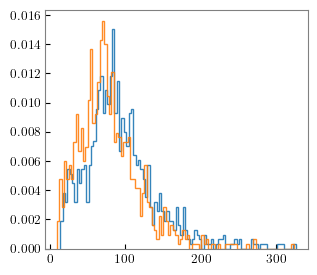

In [53]:
plt.hist(inj_param_df['m1'], **kwargs)
plt.hist(inj_param_df['m2'], **kwargs)